In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("ind.csv")

# Basic inspection
print("Columns:\n", df.columns)
print("\nFirst 5 rows:\n", df.head())
print("\nInfo:\n")
df.info()

Columns:
 Index(['Category', 'Sl.No.', 'Ministry/Department', 'Scheme',
       'Actuals 2021-2022 Revenue\n', 'Actuals 2021-2022 Capital',
       'Actuals 2021-2022 Total', 'Budget Estimates 2022-2023 Revenue',
       'Budget Estimates 2022-2023 Capital',
       'Budget Estimates 2022-2023 Total',
       'Revised Estimates2022-2023 Revenue',
       'Revised Estimates 2022-2023 Revenue',
       'Revised Estimates2022-2023 Total', 'Budget Estimates2023-2024 Revenue',
       'Budget Estimates2023-2024 Capital', 'Budget Estimates2023-2024 Total'],
      dtype='object')

First 5 rows:
        Category  Sl.No.                            Ministry/Department  \
0  Demand No. 1       1  Department of Agriculture and Farmers Welfare   
1  Demand No. 1       2  Department of Agriculture and Farmers Welfare   
2  Demand No. 1       3  Department of Agriculture and Farmers Welfare   
3  Demand No. 1       4  Department of Agriculture and Farmers Welfare   
4  Demand No. 1       5  Department of Agr

In [2]:
# Clean column names
df.columns = df.columns.str.strip()  # remove spaces
df.columns = df.columns.str.replace("\n", "", regex=True)

# Fix duplicate column issue (keep only one)
df = df.loc[:, ~df.columns.duplicated()]

# Fill missing values with 0
df = df.fillna(0)

# Check again
print(df.columns)

Index(['Category', 'Sl.No.', 'Ministry/Department', 'Scheme',
       'Actuals 2021-2022 Revenue', 'Actuals 2021-2022 Capital',
       'Actuals 2021-2022 Total', 'Budget Estimates 2022-2023 Revenue',
       'Budget Estimates 2022-2023 Capital',
       'Budget Estimates 2022-2023 Total',
       'Revised Estimates2022-2023 Revenue',
       'Revised Estimates 2022-2023 Revenue',
       'Revised Estimates2022-2023 Total', 'Budget Estimates2023-2024 Revenue',
       'Budget Estimates2023-2024 Capital', 'Budget Estimates2023-2024 Total'],
      dtype='object')


Which ministry gets the most budget (2023–24)?


In [3]:
top_ministries = df.groupby("Ministry/Department")["Budget Estimates2023-2024 Total"].sum()

top_ministries = top_ministries.sort_values(ascending=False)

print(top_ministries.head(10))

Ministry/Department
Ministry of Road Transport and Highways            270250.38
Ministry of Railways                               240000.00
Department of Food and Public Distribution         197868.57
Department of Fertilisers                          175103.37
Capital Outlay on Defence Services                 162600.00
Department of Agriculture and Farmers Welfare       98980.03
Ministry of Petroleum and Natural Gas               40785.60
Indirect Taxes                                      27554.59
Ministry of Housing and Urban Affairs               26444.96
Ministry of Micro, Small and Medium Enterprises     21852.55
Name: Budget Estimates2023-2024 Total, dtype: float64


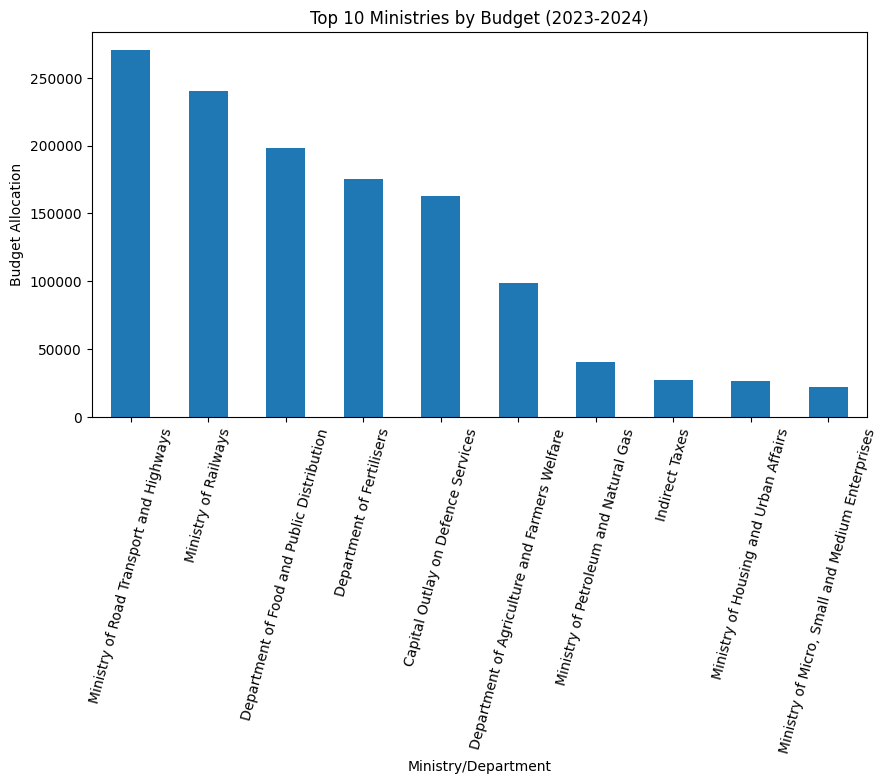

In [4]:
top_ministries.head(10).plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Ministries by Budget (2023-2024)")
plt.ylabel("Budget Allocation")
plt.xticks(rotation=75)
plt.show()

Growth Analysis

In [5]:
growth = df.groupby("Ministry/Department")[[
    "Actuals 2021-2022 Total",
    "Budget Estimates2023-2024 Total"
]].sum()

# Calculate growth %
growth["Growth %"] = ((growth["Budget Estimates2023-2024 Total"] - growth["Actuals 2021-2022 Total"])
                     / growth["Actuals 2021-2022 Total"]) * 100

growth = growth.sort_values("Growth %", ascending=False)

print(growth.head(10))

                                                    Actuals 2021-2022 Total  \
Ministry/Department                                                           
Indirect Taxes                                                         0.00   
Ministry of Cooperation                                                0.00   
Ministry of Skill Development and Entrepreneurship                     0.00   
Ministry of Petroleum and Natural Gas                               5491.33   
Ministry of Heavy Industries                                         850.69   
Department of Pharmaceuticals                                        578.39   
Ministry of Tribal Affairs                                          1421.16   
Ministry of Steel                                                      6.13   
Ministry of Food Processing Industries                               722.76   
Ministry of Tourism                                                  686.84   

                                                   

In [6]:
# Remove rows where base year = 0
growth_clean = growth[growth["Actuals 2021-2022 Total"] > 0]

# Sort again
growth_clean = growth_clean.sort_values("Growth %", ascending=False)

print(growth_clean.head(10))

                                                    Actuals 2021-2022 Total  \
Ministry/Department                                                           
Ministry of Petroleum and Natural Gas                               5491.33   
Ministry of Heavy Industries                                         850.69   
Department of Pharmaceuticals                                        578.39   
Ministry of Tribal Affairs                                          1421.16   
Ministry of Steel                                                      6.13   
Ministry of Food Processing Industries                               722.76   
Ministry of Tourism                                                  686.84   
Ministry of Electronics and Information Technology                  4504.36   
Ministry of Information and Broadcasting                             452.66   
Ministry of New and Renewable Energy                                4143.46   

                                                   

Growth vs Total

In [7]:
# Merge total + growth
analysis = growth_clean.copy()

# Sort by both growth and total
top_combined = analysis.sort_values(
    ["Budget Estimates2023-2024 Total", "Growth %"],
    ascending=[False, False]
)

print(top_combined.head(10))

                                                 Actuals 2021-2022 Total  \
Ministry/Department                                                        
Ministry of Road Transport and Highways                        123419.90   
Ministry of Railways                                           117270.54   
Department of Food and Public Distribution                     301729.45   
Department of Fertilisers                                      153758.10   
Capital Outlay on Defence Services                             137986.97   
Department of Agriculture and Farmers Welfare                  105368.88   
Ministry of Petroleum and Natural Gas                            5491.33   
Ministry of Housing and Urban Affairs                           28767.45   
Ministry of Micro, Small and Medium Enterprises                 15107.14   
Ministry of Power                                               18044.99   

                                                 Budget Estimates2023-2024 Total  \
Min

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data (example for one ministry)
sample = df[df["Ministry/Department"] == "Ministry of Road Transport and Highways"]

X = np.array([2021, 2022, 2023]).reshape(-1,1)
y = np.array([
    sample["Actuals 2021-2022 Total"].sum(),
    sample["Budget Estimates 2022-2023 Total"].sum(),
    sample["Budget Estimates2023-2024 Total"].sum()
])

model = LinearRegression()
model.fit(X, y)

# Predict 2024
prediction = model.predict([[2024]])

print("Predicted Budget for 2024-25:", prediction[0])

Predicted Budget for 2024-25: 344368.7333333492
